In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

In [5]:
class PinnHeatEq(nn.Module):
    def __init__(self):
        super().__init__()
        self.couche_entree = nn.Linear(2, 50)
        self.couche_cachee1 = nn.Linear(50, 50)
        self.couche_cachee2 = nn.Linear(50, 50)
        self.couche_sortie = nn.Linear(50, 1)

    def forward(self, x):
        x = torch.tanh(self.couche_entree(x))
        x = torch.tanh(self.couche_cachee1(x))
        x = torch.tanh(self.couche_cachee2(x))
        return self.couche_sortie(x)

In [6]:
t_min, t_max = 0.0, 1.0
x_min, x_max = 0.0, 1.0


def generer_points_collocation(n_pde):
    t_colloc = torch.rand(n_pde, 1) * (t_max - t_min) + t_min
    x_colloc = torch.rand(n_pde, 1) * (x_max - x_min) + x_min
    return t_colloc.float(), x_colloc.float()


def generer_points_initiaux(n_iv):
    t_init = torch.zeros(n_iv, 1)
    x_init = torch.rand(n_iv, 1) * (x_max - x_min) + x_min
    return t_init.float(), x_init.float()


def generer_points_bords(n_bords):
    t_bord = torch.rand(n_bords, 1) * (t_max - t_min) + t_min
    x_gauche = torch.ones(n_bords // 2, 1) * x_min
    x_droite = torch.ones(n_bords // 2, 1) * x_max
    x_bord = torch.cat([x_gauche, x_droite], dim=0)
    return t_bord.float(), x_bord.float()

In [7]:
def calc_iv_loss(model, t_init, x_init, u_exact_init):
    u_pred = model(torch.cat([t_init, x_init], dim=1))
    return torch.mean((u_pred - u_exact_init) ** 2)


def calc_bc_loss(model, t_bord, x_bord, u_exact_bord):
    u_pred = model(torch.cat([t_bord, x_bord], dim=1))
    return torch.mean((u_pred - u_exact_bord) ** 2)


def calc_clp_loss(model, t_colloc, x_colloc, alpha):
    """  Lors de cette V2 , On ajoute a la function de perte un terme de regularisation pour 
    eviter un overfitting du modèle en le penalisant dans ce cas sur la derivée troisieme par rapport à x.
    """
    lambda_reg = 0.00000001
    t_colloc.requires_grad_(True)
    x_colloc.requires_grad_(True)

    u_pred = model(torch.cat([t_colloc, x_colloc], dim=1))

    u_t = torch.autograd.grad(
        outputs=u_pred,
        inputs=t_colloc,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
    )[0]

    u_x = torch.autograd.grad(
        outputs=u_pred,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
    )[0]

    u_xx = torch.autograd.grad(
        outputs=u_x,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
    )[0]

    u_xxx =  torch.autograd.grad(
        outputs=u_xx,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(u_xx),
        create_graph=True,
    )[0]

    residu = u_t - alpha * u_xx
    return torch.mean(residu ** 2) + lambda_reg * torch.mean(u_xxx ** 2)

In [8]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

alpha = 0.0005

modele = PinnHeatEq().to(device)
optimizer = optim.Adam(modele.parameters(), lr=0.001)

t_colloc, x_colloc = generer_points_collocation(12000)
t_init, x_init = generer_points_initiaux(1000)
t_bord, x_bord = generer_points_bords(1000)

u_exact_init = torch.sin(2 * torch.pi * x_init)
u_exact_bord = torch.zeros_like(x_bord)

t_colloc, x_colloc = t_colloc.to(device), x_colloc.to(device)
t_init, x_init = t_init.to(device), x_init.to(device)
t_bord, x_bord = t_bord.to(device), x_bord.to(device)
u_exact_init = u_exact_init.to(device)
u_exact_bord = u_exact_bord.to(device)

mps


In [9]:
epochs = 12000

for epoch in range(epochs):
    optimizer.zero_grad()

    loss_iv = calc_iv_loss(modele, t_init, x_init, u_exact_init)
    loss_bc = calc_bc_loss(modele, t_bord, x_bord, u_exact_bord)
    loss_clp = calc_clp_loss(modele, t_colloc, x_colloc, alpha)

    loss_totale = 300 * loss_iv + 100 * loss_bc + loss_clp
    loss_totale.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoque {epoch:05d} | "
              f"Loss totale: {loss_totale.item():.2e} | "
              f"CLP: {loss_clp.item():.2e} | "
              f"BC: {loss_bc.item():.2e} | "
              f"IV: {loss_iv.item():.2e}")

Epoque 00000 | Loss totale: 167.757812 | CLP: 0.011094 | BC: 0.049794 | IV: 0.542558
Epoque 00100 | Loss totale: 84.209656 | CLP: 0.093835 | BC: 0.153650 | IV: 0.229170
Epoque 00200 | Loss totale: 22.231812 | CLP: 0.397774 | BC: 0.045136 | IV: 0.057735
Epoque 00300 | Loss totale: 0.653941 | CLP: 0.185315 | BC: 0.001022 | IV: 0.001221
Epoque 00400 | Loss totale: 0.324393 | CLP: 0.147515 | BC: 0.000401 | IV: 0.000456
Epoque 00500 | Loss totale: 0.197752 | CLP: 0.103314 | BC: 0.000210 | IV: 0.000245
Epoque 00600 | Loss totale: 0.125571 | CLP: 0.073169 | BC: 0.000113 | IV: 0.000137
Epoque 00700 | Loss totale: 0.172106 | CLP: 0.053554 | BC: 0.000215 | IV: 0.000323
Epoque 00800 | Loss totale: 0.058104 | CLP: 0.042602 | BC: 0.000044 | IV: 0.000037
Epoque 00900 | Loss totale: 0.098067 | CLP: 0.035079 | BC: 0.000148 | IV: 0.000161
Epoque 01000 | Loss totale: 0.036804 | CLP: 0.029399 | BC: 0.000026 | IV: 0.000016
Epoque 01100 | Loss totale: 0.031402 | CLP: 0.025257 | BC: 0.000023 | IV: 0.000013


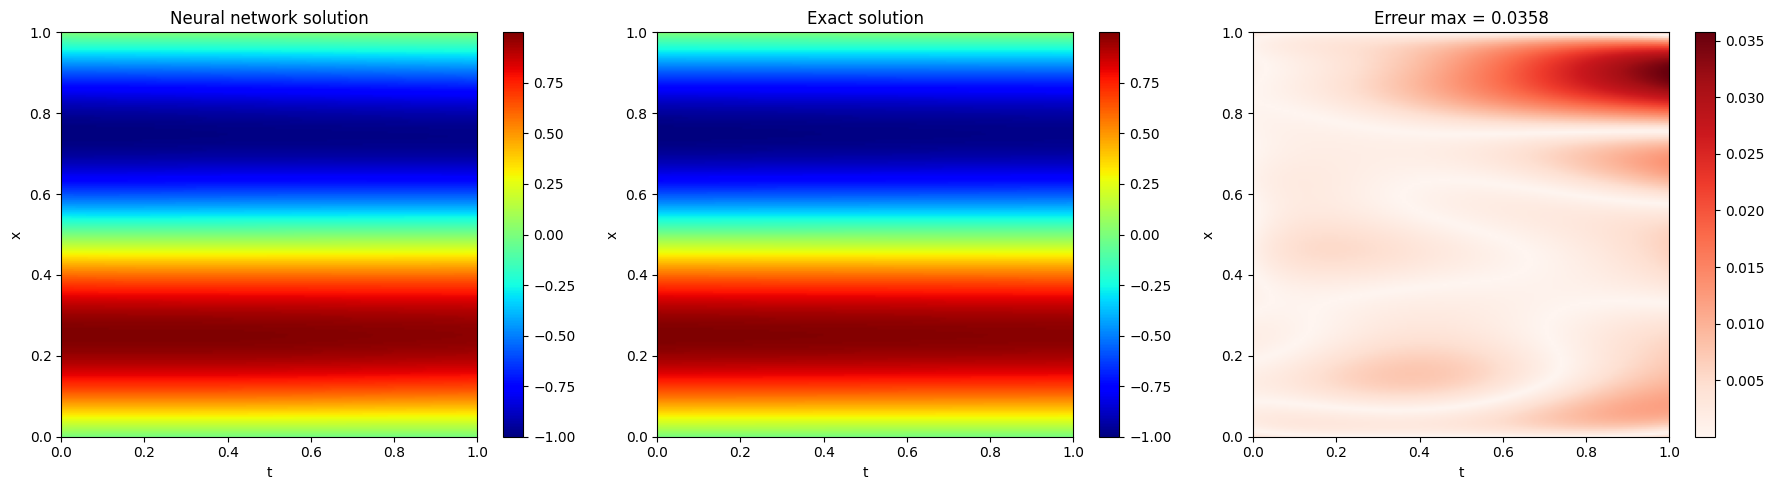

(array([[ 0.0027646 ,  0.03313665,  0.06366877, ..., -0.06373645,
         -0.03287278, -0.00217354],
        [ 0.00262319,  0.03300145,  0.06353921, ..., -0.06357492,
         -0.03271084, -0.00201181],
        [ 0.00248627,  0.03287047,  0.06341408, ..., -0.06342041,
         -0.0325567 , -0.00185771],
        ...,
        [ 0.00329275,  0.03197835,  0.06084363, ..., -0.05714767,
         -0.03057516, -0.00427487],
        [ 0.0035048 ,  0.0321707 ,  0.06101596, ..., -0.0572735 ,
         -0.03073432, -0.00446741],
        [ 0.00372313,  0.03236942,  0.06119512, ..., -0.05740436,
         -0.03089871, -0.00466517]], shape=(200, 200), dtype=float32),
 array([[ 0.00000000e+00,  3.15685498e-02,  6.31056313e-02, ...,
         -6.31056313e-02, -3.15685498e-02, -2.44929360e-16],
        [ 0.00000000e+00,  3.15654186e-02,  6.30993720e-02, ...,
         -6.30993720e-02, -3.15654186e-02, -2.44905066e-16],
        [ 0.00000000e+00,  3.15622877e-02,  6.30931134e-02, ...,
         -6.30931134e-0

In [10]:
import sys; sys.path.append("..")
import numpy as np                                                                                                    
from pinnplot import plot_solution                        

u_exact = lambda t, x: np.sin(2*np.pi*x) * np.exp(-(2*np.pi)**2 * alpha * t)

plot_solution(modele, u_exact)           
     

